## 0. Configuración y Carga de Datos

In [19]:
pip install normflows apafib

In [20]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
import normflows as nf
import time
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Usando dispositivo: {device}")

Usando dispositivo: cuda


In [21]:

from apafib import load_smile
X_raw, y = load_smile()

X_raw = X_raw.astype(np.float32)

print(f"Shape original: {X_raw.shape}")
print(f"Rango original: [{X_raw.min()}, {X_raw.max()}]")

Shape original: (1203, 3, 32, 32)
Rango original: [0.0, 1.0]


In [22]:
X = X_raw.copy()
X = (X - 0.5) * 2.0

print(f"\nRango ajustado para Glow: [{X.min():.2f}, {X.max():.2f}]")

# Verificar balance de clases ANTES de dividir
unique_all, counts_all = np.unique(y, return_counts=True)
print(f"\n{'='*50}")
print(f"BALANCE DE CLASES EN DATASET COMPLETO:")
print(f"{'='*50}")
for cls, cnt in zip(unique_all, counts_all):
    print(f"  Clase {cls} ({'Smiling' if cls == 1 else 'No Smiling'}): {cnt} muestras ({cnt/len(y)*100:.1f}%)")
print(f"{'='*50}")

# SPLIT ESTRATIFICADO: Mezclar los datos manteniendo proporción de clases
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y  # CLAVE: mantiene la misma proporción de clases en train y val
)

# Verificar balance DESPUÉS de dividir
unique_train, counts_train = np.unique(y_train, return_counts=True)
unique_val, counts_val = np.unique(y_val, return_counts=True)

print(f"\nBALANCE EN TRAIN SET (después de split estratificado):")
for cls, cnt in zip(unique_train, counts_train):
    print(f"  Clase {cls}: {cnt} muestras ({cnt/len(y_train)*100:.1f}%)")

print(f"\nBALANCE EN VAL SET (después de split estratificado):")
for cls, cnt in zip(unique_val, counts_val):
    print(f"  Clase {cls}: {cnt} muestras ({cnt/len(y_val)*100:.1f}%)")

batch_size = 64
train_dataset = TensorDataset(torch.tensor(X_train), torch.tensor(y_train).long())
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader_small = DataLoader(TensorDataset(torch.tensor(X_val[:200]), torch.tensor(y_val[:200]).long()), batch_size=64)
val_loader_real = DataLoader(TensorDataset(torch.tensor(X_val), torch.tensor(y_val).long()), batch_size=64, shuffle=False)

print(f"\n✓ Datos preparados con split estratificado")
print(f"  Train: {X_train.shape}, Val: {X_val.shape}")


Rango ajustado para Glow: [-1.00, 1.00]

BALANCE DE CLASES EN DATASET COMPLETO:
  Clase 0 (No Smiling): 603 muestras (50.1%)
  Clase 1 (Smiling): 600 muestras (49.9%)

BALANCE EN TRAIN SET (después de split estratificado):
  Clase 0: 482 muestras (50.1%)
  Clase 1: 480 muestras (49.9%)

BALANCE EN VAL SET (después de split estratificado):
  Clase 0: 121 muestras (50.2%)
  Clase 1: 120 muestras (49.8%)

✓ Datos preparados con split estratificado
  Train: (962, 3, 32, 32), Val: (241, 3, 32, 32)


### Visualización de Ejemplos Reales (Datos Originales)

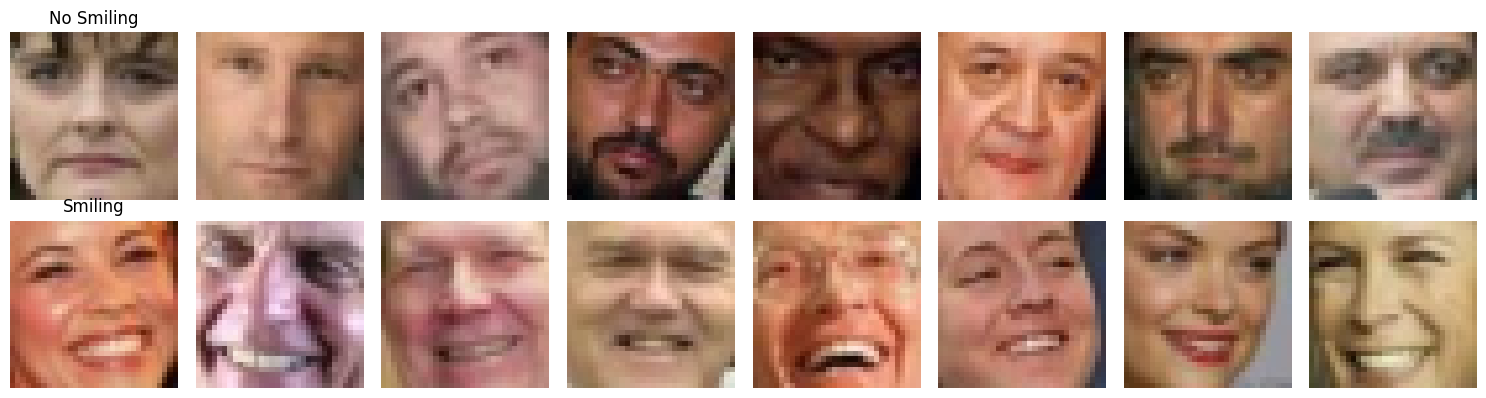

In [23]:
fig, axes = plt.subplots(2, 8, figsize=(15, 4))
for i in range(8):
    idx_0 = np.where(y == 0)[0][i]
    idx_1 = np.where(y == 1)[0][i]

    axes[0, i].imshow(X_raw[idx_0].transpose(1, 2, 0))
    axes[0, i].axis('off')

    axes[1, i].imshow(X_raw[idx_1].transpose(1, 2, 0))
    axes[1, i].axis('off')

axes[0, 0].set_title('No Smiling', fontsize=12)
axes[1, 0].set_title('Smiling', fontsize=12)
plt.tight_layout()
plt.show()

## Definición del Modelo Glow

In [24]:
def GlowModel(scales, blocks, img_size, channels, hidden_channels, num_classes, split_mode='channel'):
    L = scales
    K = blocks
    input_shape = (channels, img_size, img_size)
    scale = True

    q0 = []
    merges = []
    flows = []
    for i in range(L):
        flows_ = []
        for j in range(K):
            flows_ += [
                nf.flows.GlowBlock(channels * 2**(L + 1 - i),
                                   hidden_channels,
                                   split_mode=split_mode,
                                   scale=scale)
            ]
        flows_ += [nf.flows.Squeeze()]
        flows += [flows_]
        if i > 0:
            merges += [nf.flows.Merge()]
            latent_shape = (input_shape[0] * 2**(L - i),
                            input_shape[1] // 2**(L - i),
                            input_shape[2] // 2**(L - i))
        else:
            latent_shape = (input_shape[0] * 2**(L + 1),
                            input_shape[1] // 2**L, input_shape[2] // 2**L)

        q0 += [nf.distributions.ClassCondDiagGaussian(latent_shape, num_classes)]

    return nf.MultiscaleFlow(q0, flows, merges)
def train_glow(model, epochs, loader, desc="Training", patience=10):
    optimizer = optim.Adamax(model.parameters(), lr=1e-3, weight_decay=1e-5)
    model.train()
    loss_hist = []

    # Early stopping variables
    best_loss = float('inf')
    epochs_without_improvement = 0
    best_state = None

    total_batches = len(loader) * epochs
    pbar = tqdm(total=total_batches, desc=desc, unit="batch", leave=True)

    for epoch in range(epochs):
        running_loss = 0.0
        num_batches = 0
        nan_count = 0

        for x, y in loader:
            x, y = x.to(device), y.to(device)
            optimizer.zero_grad()

            y_onehot = F.one_hot(y, num_classes=2).float()
            loss = -model.log_prob(x, y_onehot).mean()

            # Contar NaN/Inf
            if torch.isnan(loss) | torch.isinf(loss):
                nan_count += 1
                if nan_count > 5:
                    pbar.close()
                    print(f"\nEarly stopping: Demasiados NaN/Inf detectados en epoch {epoch+1}")
                    if best_state is not None:
                        model.load_state_dict(best_state)
                        print(f"Modelo restaurado al mejor estado (loss: {best_loss:.4f})")
                    return loss_hist, loss_hist[-1] if loss_hist else float('inf')
            else:
                loss.backward()
                optimizer.step()
                running_loss += loss.item()
                num_batches += 1

            avg_loss = running_loss / max(num_batches, 1)
            pbar.update(1)
            pbar.set_postfix({'loss': f'{avg_loss:.4f}', 'epoch': f'{epoch+1}/{epochs}', 'patience': f'{epochs_without_improvement}/{patience}'})

        avg_epoch_loss = running_loss / max(num_batches, 1)
        loss_hist.append(avg_epoch_loss)

        # Early stopping: verificar mejora
        if avg_epoch_loss < best_loss:
            best_loss = avg_epoch_loss
            epochs_without_improvement = 0
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
        else:
            epochs_without_improvement += 1

        if epochs_without_improvement >= patience:
            pbar.close()
            print(f"\nEarly stopping: Sin mejora durante {patience} epochs")
            if best_state is not None:
                model.load_state_dict(best_state)
                print(f"Modelo restaurado al mejor estado (loss: {best_loss:.4f})")
            return loss_hist, best_loss

    pbar.close()
    print(f"\n✓ {desc} completado - Loss final: {loss_hist[-1]:.4f}")
    return loss_hist, loss_hist[-1]

## FASE 1: Comparativa Split Mode (Channel vs Checkerboard)

FASE 1: Comparativa 'Split Mode' (Channel vs Checkerboard)
Probando split_mode='channel'...


channel: 100%|██████████| 800/800 [00:48<00:00, 16.41batch/s, loss=-6604.7342, epoch=50/50, patience=0/10]



✓ channel completado - Loss final: -6604.7342
Probando split_mode='checkerboard'...


checkerboard: 100%|██████████| 800/800 [00:56<00:00, 14.23batch/s, loss=-6478.2832, epoch=50/50, patience=0/10]



✓ checkerboard completado - Loss final: -6478.2832


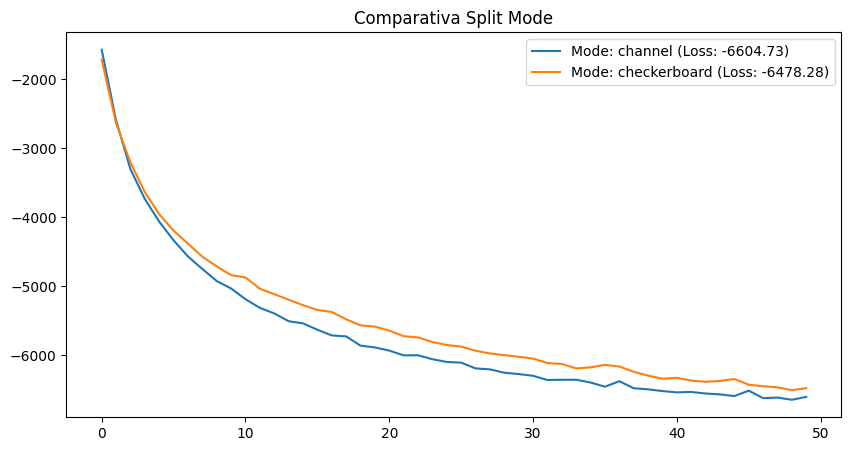

GANADOR FASE 1: channel


In [25]:
print("FASE 1: Comparativa 'Split Mode' (Channel vs Checkerboard)")
print("="*50)

exp1_scales = 3
exp1_blocks = 4
exp1_hidden = 32
exp1_epochs = 50

modes = ['channel', 'checkerboard']
best_split_mode = 'channel'
best_split_loss = float('inf')

plt.figure(figsize=(10, 5))

for mode in modes:
    print(f"Probando split_mode='{mode}'...")
    model = GlowModel(exp1_scales, exp1_blocks, 32, 3, exp1_hidden, 2, split_mode=mode).to(device)
    losses, final_loss = train_glow(model, exp1_epochs, train_loader, desc=mode)

    plt.plot(losses, label=f"Mode: {mode} (Loss: {final_loss:.2f})")

    if final_loss < best_split_loss:
        best_split_loss = final_loss
        best_split_mode = mode

plt.title("Comparativa Split Mode")
plt.legend()
plt.show()

print(f"GANADOR FASE 1: {best_split_mode}")

## FASE 2: Exploración de Hiperparámetros (Blocks & Channels)

In [26]:
print("FASE 2: Exploración de Hiperparámetros (Blocks & Channels)")
print("="*50)

configs = [
    {'blocks': 6, 'hidden': 64},
    {'blocks': 8, 'hidden': 96},
    {'blocks': 10, 'hidden': 128},
    {'blocks': 12, 'hidden': 256}
]

best_config = configs[0]
best_config_loss = float('inf')
search_epochs = 50

for conf in configs:
    b, h = conf['blocks'], conf['hidden']
    print(f"Probando Config: Blocks={b}, Hidden={h}...")

    try:
        model = GlowModel(3, b, 32, 3, h, 2, split_mode=best_split_mode).to(device)
        _, final_loss = train_glow(model, search_epochs, train_loader)

        if final_loss < best_config_loss:
            best_config_loss = final_loss
            best_config = conf
    except RuntimeError as e:
        print(f"Fallo (posiblemente OOM): {e}")

print(f"GANADOR FASE 2: {best_config}")

FASE 2: Exploración de Hiperparámetros (Blocks & Channels)
Probando Config: Blocks=6, Hidden=64...


Training: 100%|██████████| 800/800 [00:46<00:00, 17.04batch/s, loss=-7009.7835, epoch=50/50, patience=0/10]



✓ Training completado - Loss final: -7009.7835
Probando Config: Blocks=8, Hidden=96...


Training: 100%|██████████| 800/800 [01:00<00:00, 13.29batch/s, loss=-7562.9987, epoch=50/50, patience=2/10]



✓ Training completado - Loss final: -7562.9987
Probando Config: Blocks=10, Hidden=128...


Training: 100%|██████████| 800/800 [01:12<00:00, 11.08batch/s, loss=-7578.8647, epoch=50/50, patience=4/10]



✓ Training completado - Loss final: -7578.8647
Probando Config: Blocks=12, Hidden=256...


Training: 100%|██████████| 800/800 [01:39<00:00,  8.07batch/s, loss=-7746.9381, epoch=50/50, patience=4/10]


✓ Training completado - Loss final: -7746.9381
GANADOR FASE 2: {'blocks': 12, 'hidden': 256}


## FASE 3: Entrenamiento del Modelo Final

FASE 3: Entrenamiento del Modelo Final


Final Train:   8%|▊         | 2720/32000 [05:32<59:34,  8.19batch/s, loss=-8859.2156, epoch=170/2000, patience=9/10]



⚠️  Early stopping: Sin mejora durante 10 epochs
✓ Modelo restaurado al mejor estado (loss: -8930.5059)


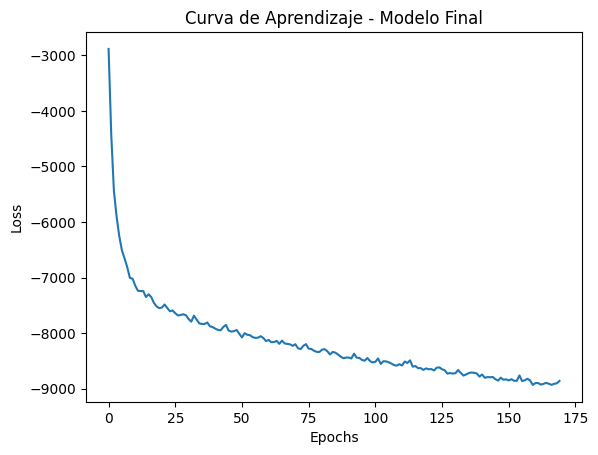

In [37]:
print("FASE 3: Entrenamiento del Modelo Final")
print("="*50)

final_epochs = 2000
final_model = GlowModel(3, best_config['blocks'], 32, 3, best_config['hidden'], 2, split_mode=best_split_mode).to(device)

loss_hist, _ = train_glow(final_model, final_epochs, train_loader, desc="Final Train")

plt.figure()
plt.plot(loss_hist)
plt.title("Curva de Aprendizaje - Modelo Final")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.show()

## FASE 4: Generación de Datos y Clasificación

In [ ]:
print("FASE 4: Generación de Datos y Clasificación")
print("="*50)

def generate_dataset_robust(model, n_samples, device, max_retries=100, temperature=1.0):
    model.eval()
    batch_gen = 32
    samples_list, labels_list = [], []
    n_per_class = n_samples // 2

    print(f"Generando {n_samples} muestras sintéticas (temperatura={temperature})...")
    with torch.no_grad():
        for class_idx in [0, 1]:
            count = 0
            consecutive_nan_batches = 0
            total_attempts = 0
            max_consecutive_nans = 20  # Más intentos antes de rendirse
            temperature_reduction_applied = False
            current_temp = temperature

            print(f"\n  Generando clase {class_idx} ({'Smiling' if class_idx == 1 else 'No Smiling'})...")

            while count < n_per_class and total_attempts < max_retries:
                curr = min(batch_gen, n_per_class - count)

                y = torch.full((curr,), class_idx, dtype=torch.long).to(device)
                y_onehot = F.one_hot(y, num_classes=2).float()

                # Intentar con temperatura ajustada si hay problemas
                try:
                    if hasattr(model, 'sample'):
                        x_gen = model.sample(curr, y=y_onehot)
                    else:
                        x_gen = model.sample(curr, y_onehot)

                    if isinstance(x_gen, tuple):
                        x_gen = x_gen[0]
                except Exception as e:
                    print(f"  Error en sampling: {e}")
                    total_attempts += 1
                    continue

                total_attempts += 1

                # Early stopping: detectar NaN o Inf
                if torch.isnan(x_gen).any() or torch.isinf(x_gen).any():
                    consecutive_nan_batches += 1

                    # Estrategia: Si muchos NaN, reducir temperatura
                    if consecutive_nan_batches == 10 and not temperature_reduction_applied and current_temp > 0.5:
                        current_temp = 0.7
                        temperature_reduction_applied = True
                        print(f"  🔧 Reduciendo temperatura a {current_temp} para clase {class_idx}")
                        consecutive_nan_batches = 0  # Reset para dar otra oportunidad
                        continue

                    if consecutive_nan_batches % 5 == 0:
                        print(f" Clase {class_idx}: {consecutive_nan_batches} batches con NaN (intento {total_attempts}/{max_retries})")

                    if consecutive_nan_batches >= max_consecutive_nans:
                        print(f"     Clase {class_idx}: Modelo no puede generar esta clase sin NaN")
                        print(f"     Muestras válidas generadas: {count}/{n_per_class}")
                        print(f"     SOLUCIÓN: Necesitas reentrenar el modelo Glow con más epochs o mejor configuración")
                        break
                    continue  # Saltar este batch e intentar de nuevo

                # Reset contador si el batch es válido
                consecutive_nan_batches = 0

                x_gen = torch.clamp(x_gen, -1.0, 1.0)

                samples_list.append(x_gen.cpu())
                labels_list.append(y.cpu())
                count += curr

            print(f"  ✓ Clase {class_idx}: {count}/{n_per_class} muestras generadas (intentos: {total_attempts})")

    # Verificar que se hayan generado muestras
    if len(samples_list) == 0:
        print("\nERROR CRÍTICO: No se pudieron generar muestras válidas")
        print("   El modelo Glow necesita ser reentrenado desde cero")
        return None, None

    X_syn = torch.cat(samples_list).numpy()
    y_syn = torch.cat(labels_list).numpy()

    # Verificar balance de clases
    unique, counts = np.unique(y_syn, return_counts=True)
    print(f"\n{'='*60}")
    print(f"✓ Generación completada: {len(X_syn)} muestras totales")
    print(f"  Balance de clases: {dict(zip(unique.tolist(), counts.tolist()))}")

    idx = np.random.permutation(len(X_syn))
    return X_syn[idx], y_syn[idx]

X_syn_train, y_syn_train = generate_dataset_robust(final_model, len(X_train), device)
X_syn_val, y_syn_val = generate_dataset_robust(final_model, len(X_val), device)

In [29]:
syn_train_loader = DataLoader(TensorDataset(torch.tensor(X_syn_train), torch.tensor(y_syn_train)), batch_size=64, shuffle=True)
syn_val_loader = DataLoader(TensorDataset(torch.tensor(X_syn_val), torch.tensor(y_syn_val)), batch_size=64, shuffle=False)
val_loader_real = DataLoader(TensorDataset(torch.tensor(X_val), torch.tensor(y_val).long()), batch_size=64, shuffle=False)

### Análisis Estadístico: Datos Reales vs Sintéticos

ANÁLISIS ESTADÍSTICO: REAL vs SINTÉTICO

Datos Reales:
  Media: -0.0104
  Std: 0.4052
  Min: -1.0000
  Max: 1.0000

Datos Sintéticos:
  Media: -0.0142
  Std: 0.3392
  Min: -1.0000
  Max: 1.0000


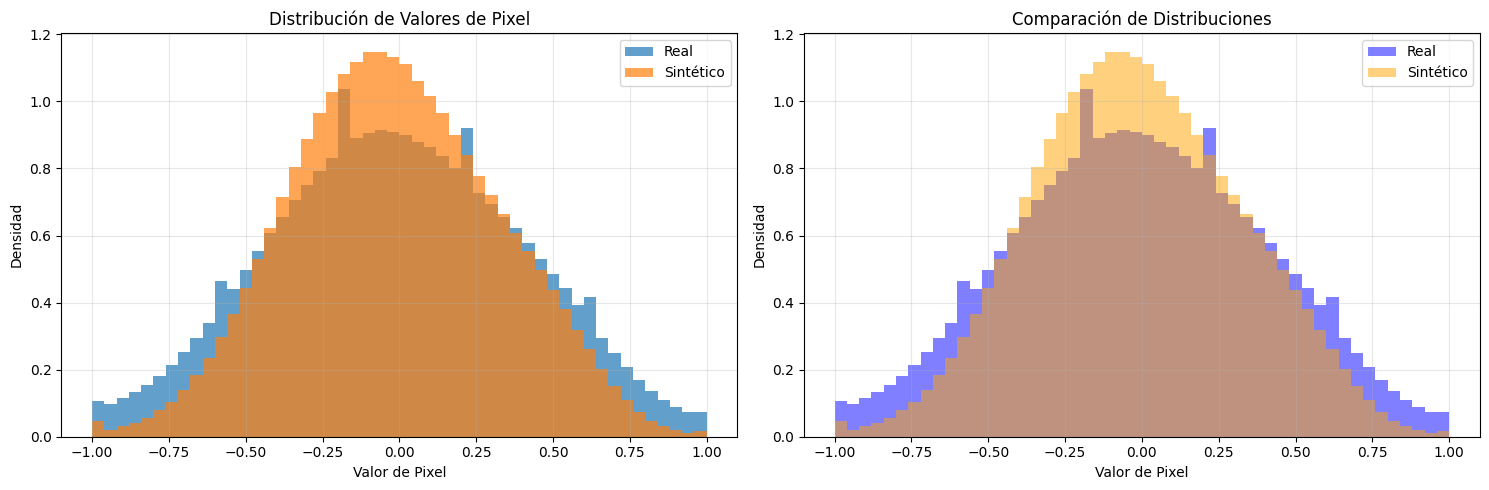

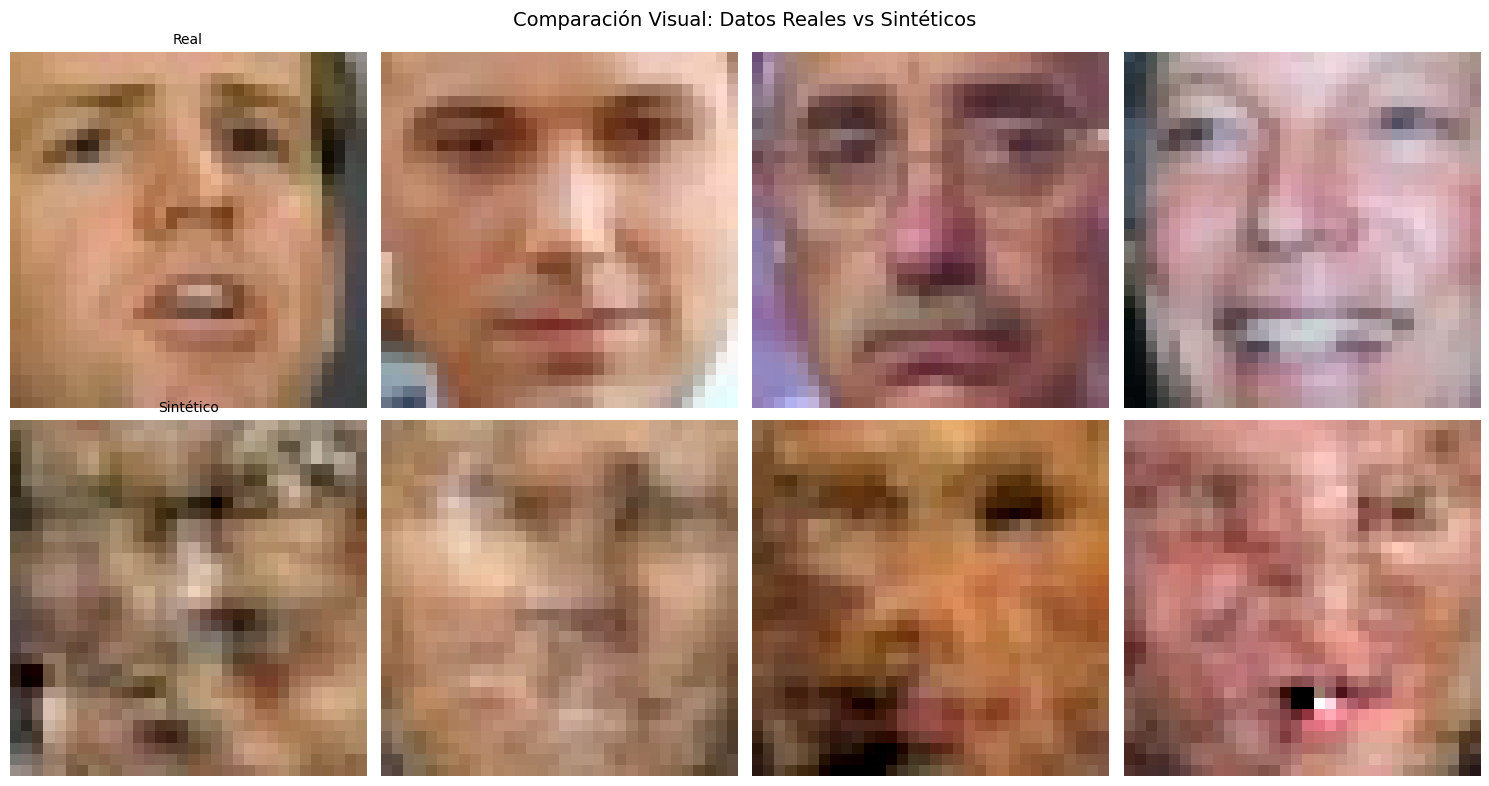

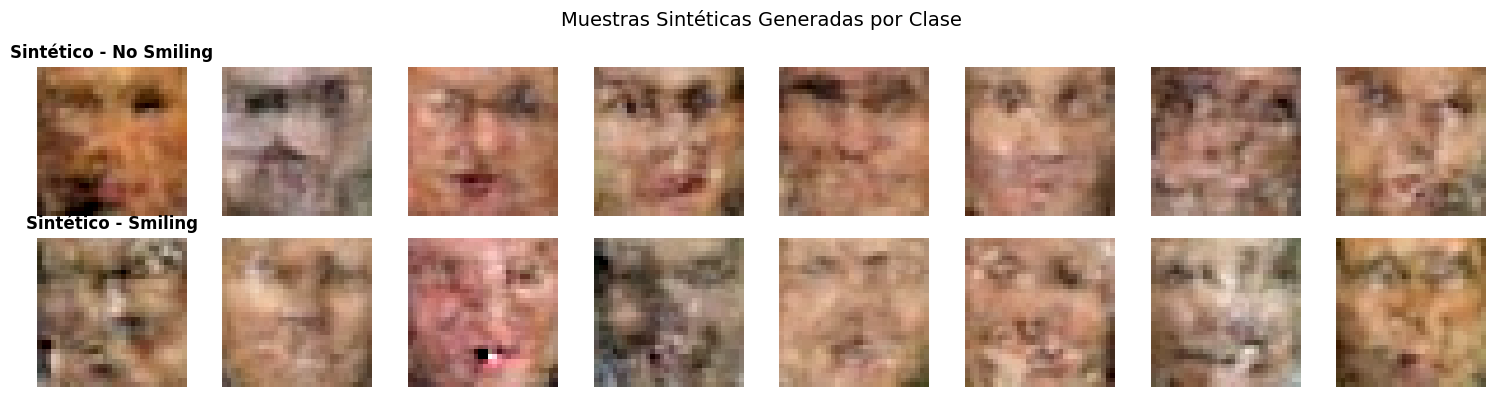

In [30]:
print("ANÁLISIS ESTADÍSTICO: REAL vs SINTÉTICO")
print("="*60)

print("\nDatos Reales:")
print(f"  Media: {X_train.mean():.4f}")
print(f"  Std: {X_train.std():.4f}")
print(f"  Min: {X_train.min():.4f}")
print(f"  Max: {X_train.max():.4f}")

print("\nDatos Sintéticos:")
print(f"  Media: {X_syn_train.mean():.4f}")
print(f"  Std: {X_syn_train.std():.4f}")
print(f"  Min: {X_syn_train.min():.4f}")
print(f"  Max: {X_syn_train.max():.4f}")

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

axes[0].hist(X_train.flatten(), bins=50, alpha=0.7, label='Real', density=True)
axes[0].hist(X_syn_train.flatten(), bins=50, alpha=0.7, label='Sintético', density=True)
axes[0].set_xlabel('Valor de Pixel')
axes[0].set_ylabel('Densidad')
axes[0].set_title('Distribución de Valores de Pixel')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].hist(X_train.flatten(), bins=50, alpha=0.5, label='Real', density=True, color='blue')
axes[1].hist(X_syn_train.flatten(), bins=50, alpha=0.5, label='Sintético', density=True, color='orange', linestyle='--')
axes[1].set_xlabel('Valor de Pixel')
axes[1].set_ylabel('Densidad')
axes[1].set_title('Comparación de Distribuciones')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

fig, axes = plt.subplots(2, 4, figsize=(15, 8))
for i in range(4):
    img_real = np.transpose(X_train[i], (1, 2, 0))
    img_real = np.clip((img_real + 1) / 2, 0, 1)
    axes[0, i].imshow(img_real)
    axes[0, i].axis('off')
    if i == 0:
        axes[0, i].set_title('Real', fontsize=10)

    img_syn = np.transpose(X_syn_train[i], (1, 2, 0))
    img_syn = np.clip((img_syn + 1) / 2, 0, 1)
    axes[1, i].imshow(img_syn)
    axes[1, i].axis('off')
    if i == 0:
        axes[1, i].set_title('Sintético', fontsize=10)

plt.suptitle('Comparación Visual: Datos Reales vs Sintéticos', fontsize=14)
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(2, 8, figsize=(15, 4))

idx_syn_0 = np.where(y_syn_train == 0)[0]
idx_syn_1 = np.where(y_syn_train == 1)[0]

for i in range(8):
    img_0 = np.transpose(X_syn_train[idx_syn_0[i]], (1, 2, 0))
    img_0 = np.clip((img_0 + 1) / 2, 0, 1)
    axes[0, i].imshow(img_0)
    axes[0, i].axis('off')

    img_1 = np.transpose(X_syn_train[idx_syn_1[i]], (1, 2, 0))
    img_1 = np.clip((img_1 + 1) / 2, 0, 1)
    axes[1, i].imshow(img_1)
    axes[1, i].axis('off')

axes[0, 0].set_title('Sintético - No Smiling', fontsize=12, fontweight='bold')
axes[1, 0].set_title('Sintético - Smiling', fontsize=12, fontweight='bold')
plt.suptitle('Muestras Sintéticas Generadas por Clase', fontsize=14)
plt.tight_layout()
plt.show()

## Definición de ResNet (Clasificador)

In [31]:
class SimpleResNet(nn.Module):
    def __init__(self):
        super().__init__()
        from torchvision.models import resnet18
        self.net = resnet18(pretrained=False)
        self.net.conv1 = nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1, bias=False)
        self.net.maxpool = nn.Identity()
        self.net.fc = nn.Linear(512, 2)

    def forward(self, x):
        return self.net(x)

def train_eval_classifier(train_loader, val_loader_real, val_loader_syn, name, epochs=200):
    net = SimpleResNet().to(device)
    crit = nn.CrossEntropyLoss()
    opt = optim.Adam(net.parameters(), lr=1e-3)

    print(f"\nEntrenando Clasificador: {name}...")
    total_batches = len(train_loader) * epochs
    pbar = tqdm(total=total_batches, desc=name, unit="batch", leave=True)

    for e in range(epochs):
        net.train()
        for x, y in train_loader:
            x, y = x.to(device), y.to(device)
            opt.zero_grad()
            loss = crit(net(x), y)
            loss.backward()
            opt.step()

            pbar.update(1)
            pbar.set_postfix({'loss': f'{loss.item():.4f}', 'epoch': f'{e+1}/{epochs}'})

    pbar.close()

    net.eval()
    def get_acc(loader):
        corr, tot = 0, 0
        with torch.no_grad():
            for x, y in loader:
                x, y = x.to(device), y.to(device)
                _, p = torch.max(net(x), 1)
                corr += (p==y).sum().item()
                tot += y.size(0)
        return corr/tot * 100

    acc_real = get_acc(val_loader_real)
    acc_syn = get_acc(val_loader_syn)
    print(f"✓ {name} completado - Real Acc: {acc_real:.2f}% | Syn Acc: {acc_syn:.2f}%\n")
    return acc_real, acc_syn, net

## Entrenar los 3 Modelos de Clasificación

In [32]:
acc1_real, acc1_syn, net_syn = train_eval_classifier(syn_train_loader, val_loader_real, syn_val_loader, "Modelo Sintético")

acc2_real, acc2_syn, net_orig = train_eval_classifier(train_loader, val_loader_real, syn_val_loader, "Modelo Original")

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)



Entrenando Clasificador: Modelo Sintético...


Modelo Sintético: 100%|██████████| 3200/3200 [02:44<00:00, 19.47batch/s, loss=0.0140, epoch=200/200]


✓ Modelo Sintético completado - Real Acc: 83.82% | Syn Acc: 83.75%


Entrenando Clasificador: Modelo Original...


Modelo Original: 100%|██████████| 3200/3200 [02:44<00:00, 19.48batch/s, loss=0.0260, epoch=200/200]


✓ Modelo Original completado - Real Acc: 95.02% | Syn Acc: 67.92%



In [33]:
n_mix = int(0.1 * len(X_syn_train))
idx_mix = np.random.choice(len(X_syn_train), n_mix, replace=False)
X_mix = np.concatenate([X_train, X_syn_train[idx_mix]])
y_mix = np.concatenate([y_train, y_syn_train[idx_mix]])
mix_loader = DataLoader(TensorDataset(torch.tensor(X_mix), torch.tensor(y_mix).long()), batch_size=64, shuffle=True)

acc3_real, acc3_syn, net_mix = train_eval_classifier(mix_loader, val_loader_real, syn_val_loader, "Modelo Mixto (10%)")


Entrenando Clasificador: Modelo Mixto (10%)...


Modelo Mixto (10%): 100%|██████████| 3400/3400 [03:04<00:00, 18.48batch/s, loss=0.0003, epoch=200/200]


✓ Modelo Mixto (10%) completado - Real Acc: 94.61% | Syn Acc: 75.42%



## Reporte de Resultados

In [34]:
print("="*60)
print(f"{'Modelo':<25} | {'Val REAL Acc':<15} | {'Val SINTÉTICO Acc':<15}")
print("-" * 60)
print(f"{'1. Sintético':<25} | {acc1_real:<15.2f} | {acc1_syn:<15.2f}")
print(f"{'2. Original':<25} | {acc2_real:<15.2f} | {acc2_syn:<15.2f}")
print(f"{'3. Mixto (10%)':<25} | {acc3_real:<15.2f} | {acc3_syn:<15.2f}")
print("="*60)

Modelo                    | Val REAL Acc    | Val SINTÉTICO Acc
------------------------------------------------------------
1. Sintético              | 83.82           | 83.75          
2. Original               | 95.02           | 67.92          
3. Mixto (10%)            | 94.61           | 75.42          


## Análisis Detallado: Confusion Matrices y Classification Reports

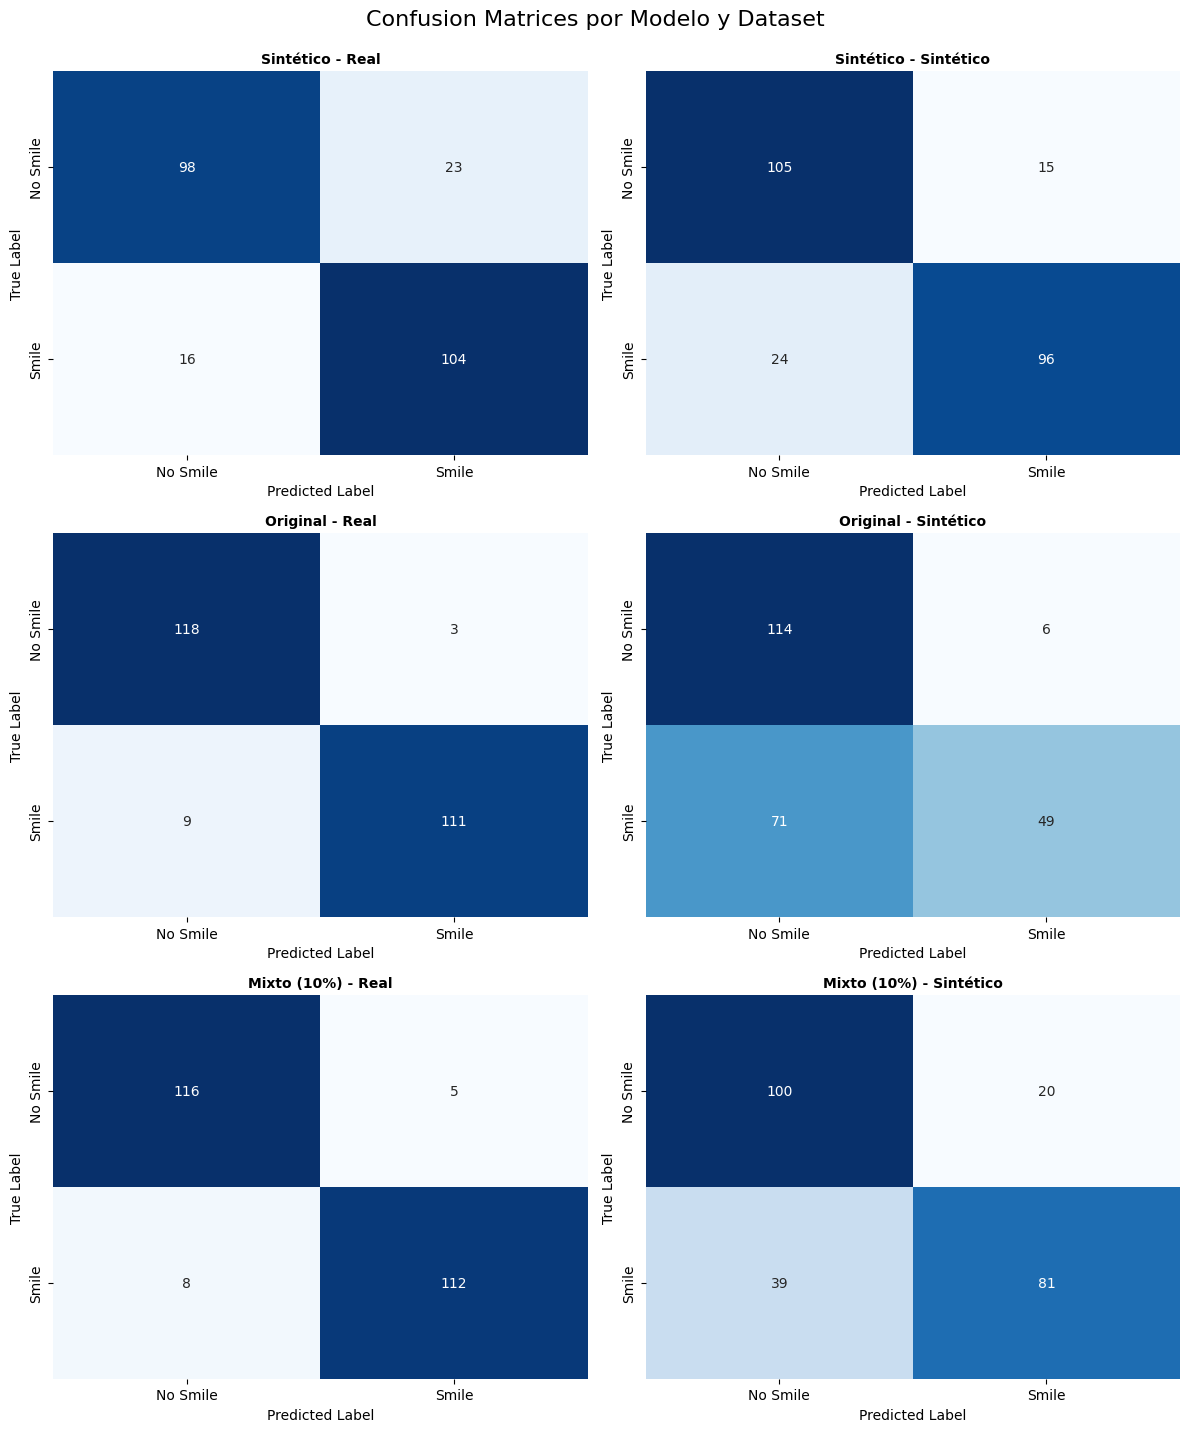

CLASSIFICATION REPORTS DETALLADOS

MODELO: Sintético

Evaluating on Real Dataset:
----------------------------------------------------------------------
              precision    recall  f1-score   support

  No Smiling     0.8596    0.8099    0.8340       121
     Smiling     0.8189    0.8667    0.8421       120

    accuracy                         0.8382       241
   macro avg     0.8393    0.8383    0.8381       241
weighted avg     0.8394    0.8382    0.8381       241


Evaluating on Sintético Dataset:
----------------------------------------------------------------------
              precision    recall  f1-score   support

  No Smiling     0.8140    0.8750    0.8434       120
     Smiling     0.8649    0.8000    0.8312       120

    accuracy                         0.8375       240
   macro avg     0.8394    0.8375    0.8373       240
weighted avg     0.8394    0.8375    0.8373       240


MODELO: Original

Evaluating on Real Dataset:
-----------------------------------------

In [35]:
models_eval = {
    'Sintético': net_syn,
    'Original': net_orig,
    'Mixto (10%)': net_mix
}

datasets_eval = {
    'Real': val_loader_real,
    'Sintético': syn_val_loader
}

eval_results = {}

for model_name, model in models_eval.items():
    model.eval()
    eval_results[model_name] = {}

    for dataset_name, loader in datasets_eval.items():
        all_preds = []
        all_labels = []

        with torch.no_grad():
            for x, y in loader:
                x, y = x.to(device), y.to(device)
                _, preds = torch.max(model(x), 1)
                all_preds.extend(preds.cpu().numpy())
                all_labels.extend(y.cpu().numpy())

        eval_results[model_name][dataset_name] = {
            'preds': np.array(all_preds),
            'labels': np.array(all_labels)
        }

fig, axes = plt.subplots(3, 2, figsize=(12, 14))

for i, (model_name, _) in enumerate(models_eval.items()):
    for j, (dataset_name, _) in enumerate(datasets_eval.items()):
        ax = axes[i, j]

        preds = eval_results[model_name][dataset_name]['preds']
        labels = eval_results[model_name][dataset_name]['labels']

        cm = confusion_matrix(labels, preds)
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax, cbar=False)

        ax.set_title(f'{model_name} - {dataset_name}', fontsize=10, fontweight='bold')
        ax.set_ylabel('True Label')
        ax.set_xlabel('Predicted Label')
        ax.set_xticklabels(['No Smile', 'Smile'])
        ax.set_yticklabels(['No Smile', 'Smile'])

plt.tight_layout()
plt.suptitle('Confusion Matrices por Modelo y Dataset', fontsize=16, y=1.02)
plt.show()

print("="*70)
print("CLASSIFICATION REPORTS DETALLADOS")
print("="*70)

for model_name in models_eval.keys():
    print(f"\n{'='*70}")
    print(f"MODELO: {model_name}")
    print(f"{'='*70}")

    for dataset_name in datasets_eval.keys():
        print(f"\nEvaluating on {dataset_name} Dataset:")
        print("-" * 70)

        preds = eval_results[model_name][dataset_name]['preds']
        labels = eval_results[model_name][dataset_name]['labels']

        print(classification_report(labels, preds,
                                   target_names=['No Smiling', 'Smiling'],
                                   digits=4))

## Visualización de Vecinos Más Cercanos (Nearest Neighbors)

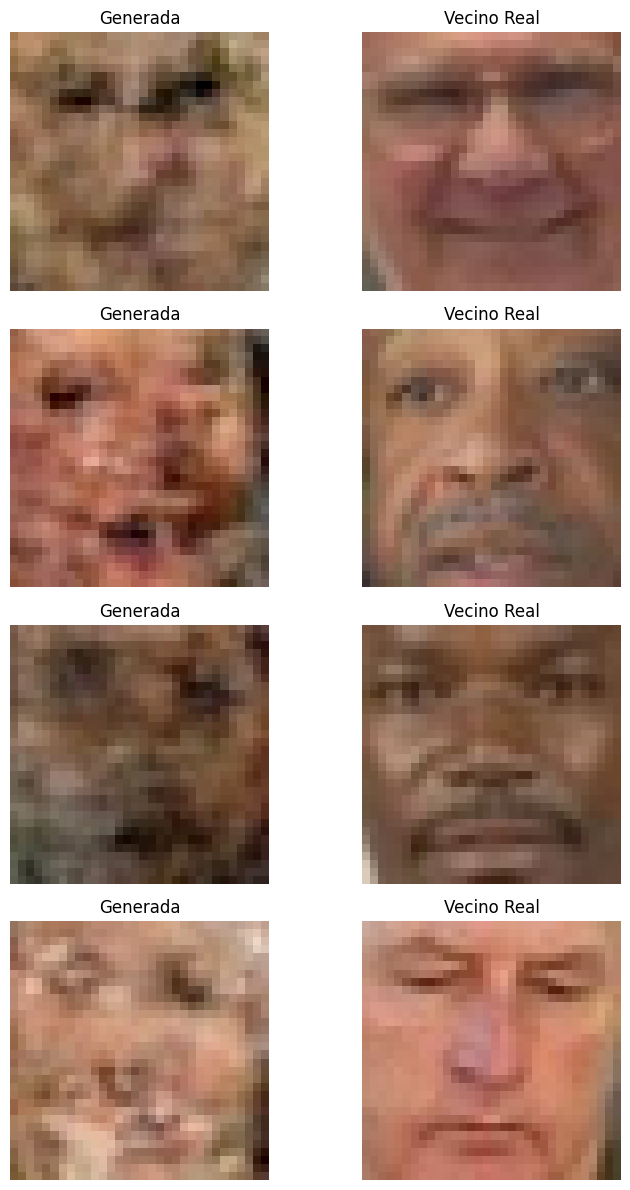

In [36]:
def plot_nearest(gen_imgs, real_imgs, n=5):
    gen_flat = gen_imgs.reshape(len(gen_imgs), -1)
    real_flat = real_imgs.reshape(len(real_imgs), -1)

    plt.figure(figsize=(8, 3*n))
    idxs = np.random.choice(len(gen_imgs), n, replace=False)

    for i, idx in enumerate(idxs):
        dists = np.linalg.norm(real_flat - gen_flat[idx], axis=1)
        nearest = real_imgs[np.argmin(dists)]

        plt.subplot(n, 2, 2*i+1)
        plt.imshow(np.clip(gen_imgs[idx].transpose(1,2,0)*0.5+0.5, 0, 1))
        plt.title("Generada")
        plt.axis('off')

        plt.subplot(n, 2, 2*i+2)
        plt.imshow(np.clip(nearest.transpose(1,2,0)*0.5+0.5, 0, 1))
        plt.title("Vecino Real")
        plt.axis('off')
    plt.tight_layout()
    plt.show()

plot_nearest(X_syn_train[:50], X_train[:2000], n=4)